In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Caminhos (Mesma lógica dos anteriores)
PROCESSED_PATH = Path('../../data/processed')
MODEL_DATA_PATH = Path('../../data/model_input')
RESULT_PATH = Path('../../data/results')

print("Ambiente configurado para Interpretabilidade.")

Ambiente configurado para Interpretabilidade.


## Recarregar Dados e Treinar o Campeão
treinando o modelo final com os parametros vencedores 

In [ ]:
X_train = pd.read_parquet(MODEL_DATA_PATH / 'X_train.parquet')
X_test = pd.read_parquet(MODEL_DATA_PATH / 'X_test.parquet')
y_train = pd.read_csv(MODEL_DATA_PATH / 'y_train.csv').values.ravel()
meta_test = pd.read_csv(MODEL_DATA_PATH / 'meta_test.csv') # Para saber o nome das cidades

# Melhores Parâmetros 
params_campeao = {
    'subsample': 0.8, 
    'n_estimators': 300, 
    'max_depth': 3, 
    'learning_rate': 0.01, 
    'colsample_bytree': 0.8,
    'use_label_encoder': False, 
    'eval_metric': 'logloss', 
    'random_state': 42
}

print("Treinando o modelo CAMPEÃO (XGBoost Tuned)...")
model = XGBClassifier(**params_campeao)
model.fit(X_train, y_train)
print("Modelo treinado!")

Treinando o modelo CAMPEÃO (XGBoost Tuned)...
Modelo treinado!


## Quais variáveis mandam?

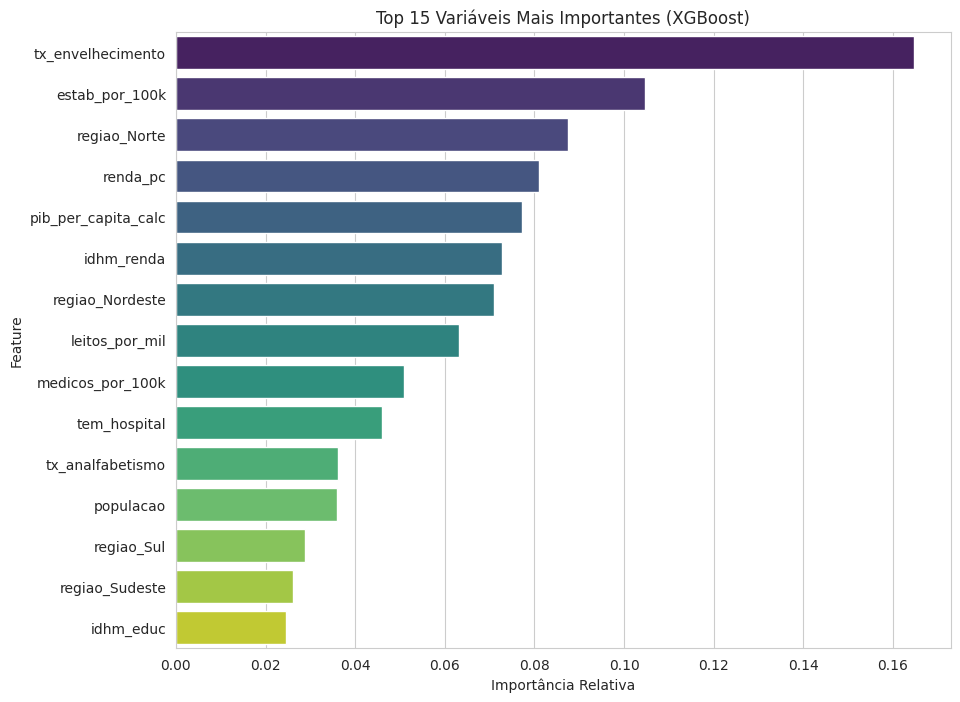

Top 5 Fatores de Risco:
                Feature  Importance
1     tx_envelhecimento    0.164710
10       estab_por_100k    0.104699
15         regiao_Norte    0.087416
6              renda_pc    0.081040
11  pib_per_capita_calc    0.077190


In [15]:
# Importância baseada no ganho de informação
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Variáveis Mais Importantes (XGBoost)')
plt.xlabel('Importância Relativa')
plt.show()

print("Top 5 Fatores de Risco:")
print(importances.head(5))

## Análise de Direção do Impacto 
Objetivo: Entender se as variáveis mais importantes aumentam ou diminuem o risco

Analisando impacto das Top 4 Variáveis: ['tx_envelhecimento', 'estab_por_100k', 'regiao_Norte', 'renda_pc']


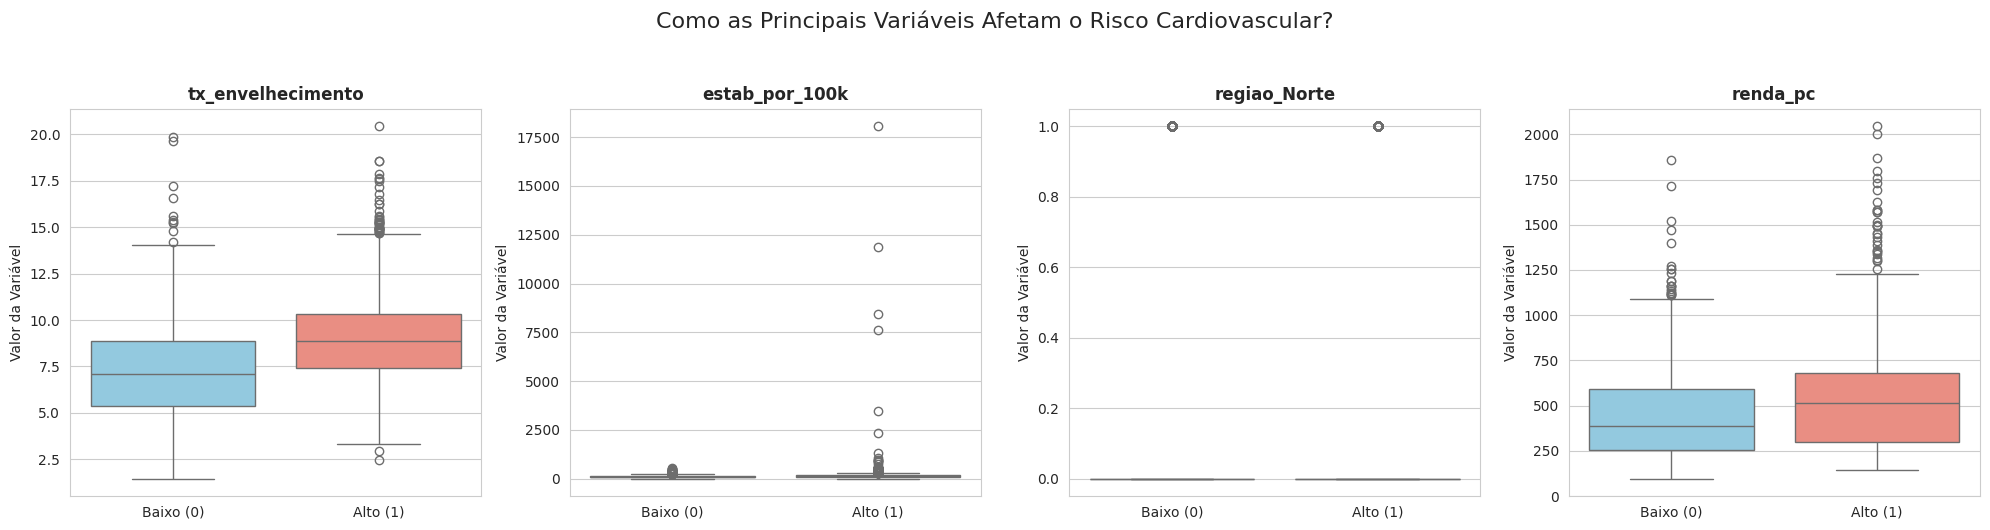

In [18]:
# O atributo feature_importances_ nos dá isso
top_indices = np.argsort(model.feature_importances_)[::-1][:4]
top_features = X_train.columns[top_indices]

print(f"Analisando impacto das Top 4 Variáveis: {list(top_features)}")

# 2. Criar DataFrame temporário para plotagem
df_plot = X_test.copy()
df_plot['Risco'] = y_test
df_plot['Risco_Label'] = df_plot['Risco'].map({0: 'Baixo (0)', 1: 'Alto (1)'})

# 3. Gerar Boxplots
plt.figure(figsize=(20, 5))

for i, col in enumerate(top_features):
    plt.subplot(1, 4, i+1)
    sns.boxplot(x='Risco_Label', y=col, data=df_plot, palette={'Baixo (0)': 'skyblue', 'Alto (1)': 'salmon'})
    plt.title(f'{col}', fontsize=12, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Valor da Variável')

plt.suptitle('Como as Principais Variáveis Afetam o Risco Cardiovascular?', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()
